
# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 04 — Strategy Engine & Coarse Ablation

**Purpose:** translate the fixed SuperbCommand states produced by Notebook 02 into explicit tradable exposure rules and test a small number of deliberately coarse strategy variants.

This notebook does **not** optimise hyperparameters.

It tests whether the *direction* of the main portfolio actions appears sensible:

- strategic long/cash vs long/short;
- ignore pullbacks vs modestly add during pullbacks;
- reduce exposure during the current `profit_taking` state;
- ignore the current `profit_taking` state;
- reinterpret the current `profit_taking` state as a modest accumulation opportunity.

### Research discipline

The current indicator state names are preserved exactly.

In particular, the Pine state remains called:

`profit_taking`

even when the strategy layer tests alternative actions such as:

`REDUCE`, `HOLD`, or `ADD`.

This prevents us from retrospectively redefining the indicator after observing Notebook 03 results.

### Execution convention

All SuperbCommand states are only known after the weekly bar closes.

Therefore:

\[
\text{Signal at week } t
\rightarrow
\text{Exposure during week } t+1
\]

The exposure series is shifted by one week before returns are calculated. This is essential to avoid look-ahead bias.


In [1]:

# ============================================================
# 4.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations

import json
import math
import sys
import platform
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 04 cannot run with the holdout unlocked.")

SIGNAL_PATH = PATHS["data_processed"] / "superbcommand_weekly_signal_panel.parquet"
META_PATH = PATHS["data_processed"] / "prototype_universe_metadata.csv"

if not SIGNAL_PATH.exists():
    raise FileNotFoundError("Run Notebook 02 first.")
if not META_PATH.exists():
    raise FileNotFoundError("Run Notebook 01 first.")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:

# ============================================================
# 4.2 — LOAD SIGNAL PANEL & METADATA
# ============================================================
panel = pd.read_parquet(SIGNAL_PATH)
meta = pd.read_csv(META_PATH, index_col=0)

try:
    panel = panel.reorder_levels(["date", "ticker"]).sort_index()
except Exception:
    panel = panel.sort_index()

dates = panel.index.get_level_values("date")
if dates.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination detected.")

tickers = sorted(panel.index.get_level_values("ticker").unique())

print("Signal rows:", len(panel))
print("Markets:", len(tickers))
print("Date range:", dates.min().date(), "→", dates.max().date())


Signal rows: 11370
Markets: 11
Date range: 2005-01-07 → 2025-12-26



## 4.3 Coarse strategy variants

The following values are **not optimised**.

They are simple test intensities designed to answer whether a state should:

- reduce exposure;
- do nothing;
- increase exposure.

Normal established trend exposure is fixed at **1.00×**.

A modest accumulation state is represented by **1.25×** exposure.

A modest profit-state reduction is represented by **0.75×** exposure.

A lighter reinterpretation of the profit state as accumulation is represented by **1.10×** exposure.

These coarse values intentionally avoid fine tuning.


In [3]:

# ============================================================
# 4.3 — DEFINE FIXED ABLATION VARIANTS
# ============================================================
VARIANTS = pd.DataFrame(
    [
        ("CORE",                     1.00, 1.00, "Ignore pullback sizing and profit-state sizing"),
        ("PB_ADD_25",                1.25, 1.00, "Add 25% during pullback"),
        ("PT_REDUCE_25",             1.00, 0.75, "Reduce 25% during profit_taking"),
        ("PB_ADD25_PT_REDUCE25",     1.25, 0.75, "Add on pullback; reduce on profit_taking"),
        ("PT_ADD_25",                1.00, 1.25, "Treat profit_taking as 25% accumulation"),
        ("PB_ADD25_PT_ADD25",        1.25, 1.25, "Add 25% in both states"),
        ("PB_ADD25_PT_ADD10",        1.25, 1.10, "Stronger pullback add; lighter profit-state add"),
    ],
    columns=["variant", "pullback_exposure", "profit_state_exposure", "description"]
).set_index("variant")

display(VARIANTS)


,pullback_exposure,profit_state_exposure,description
variant,,,
CORE,1.00,1.00,Ignore pullback sizing and profit-state sizing
PB_ADD_25,1.25,1.00,Add 25% during pullback
PT_REDUCE_25,1.00,0.75,Reduce 25% during profit_taking
PB_ADD25_PT_REDUCE25,1.25,0.75,Add on pullback; reduce on profit_taking
PT_ADD_25,1.00,1.25,Treat profit_taking as 25% accumulation
PB_ADD25_PT_ADD25,1.25,1.25,Add 25% in both states
PB_ADD25_PT_ADD10,1.25,1.10,Stronger pullback add; lighter profit-state add



## 4.4 Direction modes

Every ablation variant is tested in two strategic modes.

### Long / cash

When `position_held == False`:

\[
w_t = 0
\]

### Long / short

When `position_held == False`:

\[
w_t = -1
\]

This is intentionally simple. Notebook 04 does **not** optimise short intensity.

The purpose is to determine whether converting strategic exits into symmetric short exposure is directionally useful.


In [4]:

# ============================================================
# 4.4 — STRATEGY SETTINGS
# ============================================================
DIRECTION_MODES = ("long_cash", "long_short")

NORMAL_LONG_EXPOSURE = 1.00
STANDBY_EXPOSURE = 1.00
EARLY_REVERSAL_EXPOSURE = 1.00

# Coarse prototype execution costs.
# Weekly target-exposure changes incur these costs on absolute turnover.
ONE_WAY_COST_BPS = (
    float(CFG["defaults"]["transaction_cost_bps_one_way"])
    + float(CFG["defaults"]["slippage_bps_one_way"])
)
ONE_WAY_COST = ONE_WAY_COST_BPS / 10_000

TRADING_WEEKS_PER_YEAR = 52

print("Direction modes:", DIRECTION_MODES)
print("One-way prototype cost:", f"{ONE_WAY_COST_BPS:.1f} bps")


Direction modes: ('long_cash', 'long_short')
One-way prototype cost: 3.0 bps



## 4.5 Exposure mapping

The indicator state and the strategy action remain separate.

For any active strategic holding:

- Early Reversal → 1.00×
- Held Neutral → 1.00×
- Standby → 1.00×
- Pullback → variant-specific exposure
- Profit-Taking state → variant-specific exposure

When strategically out:

- long/cash → 0.00×
- long/short → -1.00×

The exposure decided from the close of week \(t\) is applied to week \(t+1\).


In [5]:

# ============================================================
# 4.5 — TARGET EXPOSURE ENGINE
# ============================================================
def target_exposure_from_state(df, pullback_exposure, profit_state_exposure, direction_mode):
    x = pd.Series(index=df.index, dtype=float)

    out_exposure = 0.0 if direction_mode == "long_cash" else -1.0

    for i in range(len(df)):
        held = bool(df["position_held"].iat[i])

        if not held:
            x.iat[i] = out_exposure
        elif bool(df["standby_active"].iat[i]):
            x.iat[i] = STANDBY_EXPOSURE
        elif bool(df["early_reversal_active"].iat[i]):
            x.iat[i] = EARLY_REVERSAL_EXPOSURE
        elif bool(df["pullback_active"].iat[i]):
            x.iat[i] = pullback_exposure
        elif bool(df["profit_taking_active"].iat[i]):
            x.iat[i] = profit_state_exposure
        else:
            x.iat[i] = NORMAL_LONG_EXPOSURE

    return x



## 4.6 Backtest mechanics

For each market and strategy variant:

1. calculate weekly close-to-close return;
2. determine the target exposure from the state at each weekly close;
3. shift target exposure by one week;
4. calculate turnover from changes in implemented exposure;
5. deduct simple prototype transaction costs;
6. compound strategy returns.

No volatility scaling, covariance weighting, ERC, portfolio leverage or volatility targeting is used here.

Those belong to Notebook 05.


In [6]:

# ============================================================
# 4.6 — SINGLE-MARKET BACKTEST FUNCTION
# ============================================================
def backtest_market(df, pullback_exposure, profit_state_exposure, direction_mode):
    out = df.copy()

    out["asset_return"] = out["close"].pct_change(fill_method=None)

    out["target_exposure"] = target_exposure_from_state(
        out,
        pullback_exposure=pullback_exposure,
        profit_state_exposure=profit_state_exposure,
        direction_mode=direction_mode,
    )

    # Strict no-lookahead convention.
    out["exposure"] = out["target_exposure"].shift(1)

    # Turnover occurs when implemented exposure changes.
    out["turnover"] = out["exposure"].diff().abs()

    # Initial establishment is also a trade if exposure is non-zero.
    first_valid = out["exposure"].first_valid_index()
    if first_valid is not None:
        out.loc[first_valid, "turnover"] = abs(out.loc[first_valid, "exposure"])

    out["transaction_cost"] = out["turnover"].fillna(0.0) * ONE_WAY_COST

    out["gross_strategy_return"] = out["exposure"] * out["asset_return"]
    out["net_strategy_return"] = (
        out["gross_strategy_return"].fillna(0.0)
        - out["transaction_cost"].fillna(0.0)
    )

    out["equity_curve"] = (1.0 + out["net_strategy_return"]).cumprod()

    return out


In [7]:

# ============================================================
# 4.7 — PERFORMANCE METRICS
# ============================================================
def max_drawdown_from_returns(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    return float(dd.min())

def annualised_return(r, periods=TRADING_WEEKS_PER_YEAR):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / periods
    if years <= 0 or wealth <= 0:
        return np.nan
    return wealth ** (1 / years) - 1

def annualised_vol(r, periods=TRADING_WEEKS_PER_YEAR):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return np.nan
    return float(r.std(ddof=1) * np.sqrt(periods))

def sharpe_ratio(r, periods=TRADING_WEEKS_PER_YEAR):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(periods))

def sortino_ratio(r, periods=TRADING_WEEKS_PER_YEAR):
    r = pd.Series(r).dropna()
    downside = r[r < 0]
    if len(r) < 2 or len(downside) < 2 or downside.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / downside.std(ddof=1) * np.sqrt(periods))

def calmar_ratio(r):
    cagr = annualised_return(r)
    mdd = max_drawdown_from_returns(r)
    if pd.isna(cagr) or pd.isna(mdd) or mdd == 0:
        return np.nan
    return float(cagr / abs(mdd))

def performance_metrics(r, turnover=None):
    r = pd.Series(r).dropna()
    result = {
        "cagr": annualised_return(r),
        "ann_vol": annualised_vol(r),
        "sharpe": sharpe_ratio(r),
        "sortino": sortino_ratio(r),
        "max_drawdown": max_drawdown_from_returns(r),
        "calmar": calmar_ratio(r),
        "best_week": r.max() if len(r) else np.nan,
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }

    if turnover is not None:
        t = pd.Series(turnover).fillna(0.0)
        result["annual_turnover"] = float(t.mean() * TRADING_WEEKS_PER_YEAR)
        result["total_turnover"] = float(t.sum())

    return result



## 4.8 Run all fixed variants

The complete test set is:

\[
7\ \text{state-action variants}
\times
2\ \text{direction modes}
=
14\ \text{strategies per market}.
\]

This is a deliberately small ablation experiment, not a parameter search.


In [8]:

# ============================================================
# 4.8 — RUN ALL MARKET / VARIANT / DIRECTION COMBINATIONS
# ============================================================
backtests = {}
metric_rows = []

for ticker in tickers:
    df = panel.xs(ticker, level="ticker").copy()

    for variant, spec in VARIANTS.iterrows():
        for direction_mode in DIRECTION_MODES:
            bt = backtest_market(
                df,
                pullback_exposure=float(spec["pullback_exposure"]),
                profit_state_exposure=float(spec["profit_state_exposure"]),
                direction_mode=direction_mode,
            )

            key = (ticker, variant, direction_mode)
            backtests[key] = bt

            m = performance_metrics(
                bt["net_strategy_return"],
                turnover=bt["turnover"],
            )

            metric_rows.append({
                "ticker": ticker,
                "asset_class": meta.loc[ticker, "asset_class"],
                "market_name": meta.loc[ticker, "market_name"],
                "variant": variant,
                "direction_mode": direction_mode,
                **m,
            })

market_metrics = pd.DataFrame(metric_rows)

print("Backtests completed:", len(backtests))
display(market_metrics.head())


Backtests completed: 154


,ticker,asset_class,market_name,variant,direction_mode,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate,annual_turnover,total_turnover
0,BTC-USD,crypto,Bitcoin,CORE,long_cash,0.615366,0.574115,1.118090,1.501108,-0.656423,0.937453,0.509658,-0.390115,0.376910,0.441426,5.0
1,BTC-USD,crypto,Bitcoin,CORE,long_short,0.431796,0.672142,0.869694,1.313581,-0.835227,0.516980,0.509658,-0.390115,0.536503,0.971138,11.0
2,BTC-USD,crypto,Bitcoin,PB_ADD_25,long_cash,0.613879,0.603271,1.091198,1.447945,-0.715019,0.858548,0.509658,-0.390115,0.376910,0.838710,9.5
3,BTC-USD,crypto,Bitcoin,PB_ADD_25,long_short,0.430478,0.697237,0.861879,1.300435,-0.835227,0.515402,0.509658,-0.390115,0.536503,1.368421,15.5
4,BTC-USD,crypto,Bitcoin,PT_REDUCE_25,long_cash,0.628994,0.567653,1.138488,1.550011,-0.674561,0.932450,0.509658,-0.390115,0.376910,0.794567,9.0



## 4.9 Simple equal-weight research aggregate

Notebook 05 will handle proper portfolio construction.

However, Notebook 04 needs a neutral way to compare strategy variants across the universe.

Therefore, for **ablation only**, we construct a simple equal-weight return across all markets that have a valid return in a given week.

This is not the intended final portfolio.


In [9]:

# ============================================================
# 4.9 — EQUAL-WEIGHT ABLATION AGGREGATE
# ============================================================
aggregate_returns = {}
aggregate_metrics_rows = []

for variant in VARIANTS.index:
    for direction_mode in DIRECTION_MODES:
        series_list = []

        for ticker in tickers:
            bt = backtests[(ticker, variant, direction_mode)]
            s = bt["net_strategy_return"].rename(ticker)
            series_list.append(s)

        ret_matrix = pd.concat(series_list, axis=1).sort_index()

        # Equal weight only across markets with available returns that week.
        portfolio_return = ret_matrix.mean(axis=1, skipna=True)
        aggregate_returns[(variant, direction_mode)] = portfolio_return

        m = performance_metrics(portfolio_return)

        aggregate_metrics_rows.append({
            "variant": variant,
            "direction_mode": direction_mode,
            **m,
        })

aggregate_metrics = pd.DataFrame(aggregate_metrics_rows)

display(
    aggregate_metrics.sort_values(
        ["direction_mode", "sharpe"],
        ascending=[True, False]
    )
)


,variant,direction_mode,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
4,PT_REDUCE_25,long_cash,0.069413,0.067207,1.032869,1.325866,-0.131455,0.528036,0.046219,-0.091226,0.512329
0,CORE,long_cash,0.070072,0.068501,1.023648,1.310705,-0.137594,0.509270,0.048195,-0.093356,0.511416
8,PT_ADD_25,long_cash,0.070416,0.069967,1.008261,1.284785,-0.143757,0.489829,0.050158,-0.095526,0.510502
6,PB_ADD25_PT_REDUCE25,long_cash,0.070910,0.070559,1.006939,1.280548,-0.141871,0.499816,0.049489,-0.096753,0.511416
2,PB_ADD_25,long_cash,0.071568,0.071820,0.999096,1.269082,-0.147949,0.483734,0.051465,-0.098883,0.510502
12,PB_ADD25_PT_ADD10,long_cash,0.071744,0.072370,0.994314,1.261543,-0.150378,0.477090,0.052250,-0.099740,0.510502
10,PB_ADD25_PT_ADD25,long_cash,0.072003,0.073245,0.986628,1.248756,-0.154013,0.467512,0.053427,-0.101026,0.510502
3,PB_ADD_25,long_short,0.047185,0.085665,0.581365,0.804875,-0.334890,0.140896,0.051465,-0.098883,0.539726
7,PB_ADD25_PT_REDUCE25,long_short,0.046545,0.084563,0.580599,0.804833,-0.330787,0.140711,0.049489,-0.096753,0.544292
1,CORE,long_short,0.045716,0.082976,0.580517,0.805944,-0.336333,0.135925,0.048195,-0.093356,0.541553



## 4.10 Core ablation comparisons

The most important comparisons are relative rather than absolute.

### Pullback effect

\[
PB\_ADD\_25 - CORE
\]

### Current profit-state reduction effect

\[
PT\_REDUCE\_25 - CORE
\]

### Current profit-state accumulation effect

\[
PT\_ADD\_25 - CORE
\]

### Long/short effect

\[
Long/Short - Long/Cash
\]

These comparisons help isolate the contribution of each design choice.


In [10]:

# ============================================================
# 4.10 — AGGREGATE ABLATION DELTAS
# ============================================================
agg = aggregate_metrics.set_index(["variant", "direction_mode"])

comparisons = []

def compare(a_variant, a_mode, b_variant, b_mode, label):
    a = agg.loc[(a_variant, a_mode)]
    b = agg.loc[(b_variant, b_mode)]
    comparisons.append({
        "comparison": label,
        "delta_cagr": a["cagr"] - b["cagr"],
        "delta_sharpe": a["sharpe"] - b["sharpe"],
        "delta_sortino": a["sortino"] - b["sortino"],
        "delta_max_drawdown": a["max_drawdown"] - b["max_drawdown"],
        "delta_calmar": a["calmar"] - b["calmar"],
    })

for mode in DIRECTION_MODES:
    compare("PB_ADD_25", mode, "CORE", mode, f"Pullback +25 vs Core ({mode})")
    compare("PT_REDUCE_25", mode, "CORE", mode, f"Profit-state -25 vs Core ({mode})")
    compare("PT_ADD_25", mode, "CORE", mode, f"Profit-state +25 vs Core ({mode})")
    compare("PB_ADD25_PT_ADD10", mode, "CORE", mode, f"PB +25 / PT +10 vs Core ({mode})")

compare("CORE", "long_short", "CORE", "long_cash", "Core Long/Short vs Core Long/Cash")

ablation_deltas = pd.DataFrame(comparisons)
display(ablation_deltas)


,comparison,delta_cagr,delta_sharpe,delta_sortino,delta_max_drawdown,delta_calmar
0,Pullback +25 vs Core (long_cash),0.001495,-0.024552,-0.041622,-0.010355,-0.025536
1,Profit-state -25 vs Core (long_cash),-0.000659,0.009221,0.015161,0.006139,0.018766
2,Profit-state +25 vs Core (long_cash),0.000344,-0.015387,-0.025920,-0.006163,-0.019440
3,PB +25 / PT +10 vs Core (long_cash),0.001671,-0.029334,-0.049162,-0.012784,-0.032180
4,Pullback +25 vs Core (long_short),0.001469,0.000848,-0.001069,0.001443,0.004971
5,Profit-state -25 vs Core (long_short),-0.000640,-0.000708,0.000405,0.004092,-0.000253
6,Profit-state +25 vs Core (long_short),0.000332,-0.003670,-0.007432,-0.004448,-0.000800
7,PB +25 / PT +10 vs Core (long_short),0.001639,-0.000030,-0.003012,-0.000297,0.004748
8,Core Long/Short vs Core Long/Cash,-0.024356,-0.443130,-0.504760,-0.198739,-0.373344



## 4.11 Market-consistency test

An aggregate improvement is less convincing if it comes from only one market.

For each variant, Notebook 04 therefore counts how many individual markets improve their Sharpe ratio relative to the corresponding Core strategy.


In [11]:

# ============================================================
# 4.11 — MARKET-LEVEL CONSISTENCY
# ============================================================
core_metrics = market_metrics[market_metrics["variant"] == "CORE"][
    ["ticker", "direction_mode", "sharpe", "cagr", "max_drawdown"]
].rename(columns={
    "sharpe": "core_sharpe",
    "cagr": "core_cagr",
    "max_drawdown": "core_max_drawdown",
})

consistency = market_metrics.merge(
    core_metrics,
    on=["ticker", "direction_mode"],
    how="left"
)

consistency["sharpe_improvement"] = consistency["sharpe"] - consistency["core_sharpe"]
consistency["cagr_improvement"] = consistency["cagr"] - consistency["core_cagr"]

consistency_summary = (
    consistency
    .groupby(["variant", "direction_mode"])
    .agg(
        markets=("ticker", "count"),
        markets_sharpe_improved=("sharpe_improvement", lambda x: int((x > 0).sum())),
        median_sharpe_delta=("sharpe_improvement", "median"),
        median_cagr_delta=("cagr_improvement", "median"),
    )
    .reset_index()
)

consistency_summary["share_markets_sharpe_improved"] = (
    consistency_summary["markets_sharpe_improved"]
    / consistency_summary["markets"]
)

display(consistency_summary)


,variant,direction_mode,markets,markets_sharpe_improved,median_sharpe_delta,median_cagr_delta,share_markets_sharpe_improved
0,CORE,long_cash,11,0,0.000000,0.000000,0.000000
1,CORE,long_short,11,0,0.000000,0.000000,0.000000
2,PB_ADD25_PT_ADD10,long_cash,11,2,-0.016724,-0.000107,0.181818
3,PB_ADD25_PT_ADD10,long_short,11,4,-0.003448,-0.000102,0.363636
4,PB_ADD25_PT_ADD25,long_cash,11,1,-0.016456,0.000113,0.090909
5,PB_ADD25_PT_ADD25,long_short,11,4,-0.002769,0.000107,0.363636
6,PB_ADD25_PT_REDUCE25,long_cash,11,3,-0.010004,-0.000592,0.272727
7,PB_ADD25_PT_REDUCE25,long_short,11,4,-0.005210,-0.000587,0.363636
8,PB_ADD_25,long_cash,11,2,-0.017274,-0.000290,0.181818
9,PB_ADD_25,long_short,11,4,-0.003369,-0.000276,0.363636



## 4.12 Profit-state action: REDUCE vs HOLD vs ADD

This is the key new test suggested by Notebook 03.

For a clean comparison, pullback exposure is held constant at 1.00× while only the action taken during the current `profit_taking` state changes.


In [12]:

# ============================================================
# 4.12 — PROFIT-STATE THREE-WAY TEST
# ============================================================
profit_test_variants = ["PT_REDUCE_25", "CORE", "PT_ADD_25"]

profit_test = aggregate_metrics[
    aggregate_metrics["variant"].isin(profit_test_variants)
].copy()

profit_test["profit_state_action"] = profit_test["variant"].map({
    "PT_REDUCE_25": "REDUCE to 0.75x",
    "CORE": "HOLD at 1.00x",
    "PT_ADD_25": "ADD to 1.25x",
})

profit_test = profit_test[
    [
        "profit_state_action",
        "direction_mode",
        "cagr",
        "ann_vol",
        "sharpe",
        "sortino",
        "max_drawdown",
        "calmar",
    ]
]

display(profit_test.sort_values(["direction_mode", "sharpe"], ascending=[True, False]))


,profit_state_action,direction_mode,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar
4,REDUCE to 0.75x,long_cash,0.069413,0.067207,1.032869,1.325866,-0.131455,0.528036
0,HOLD at 1.00x,long_cash,0.070072,0.068501,1.023648,1.310705,-0.137594,0.509270
8,ADD to 1.25x,long_cash,0.070416,0.069967,1.008261,1.284785,-0.143757,0.489829
1,HOLD at 1.00x,long_short,0.045716,0.082976,0.580517,0.805944,-0.336333,0.135925
5,REDUCE to 0.75x,long_short,0.045076,0.081860,0.579810,0.806349,-0.332240,0.135672
9,ADD to 1.25x,long_short,0.046048,0.084239,0.576848,0.798512,-0.340781,0.135125



## 4.13 Long/cash vs long/short

This comparison isolates the strategic consequence of converting a SuperbCommand exit into a short position rather than cash.

Because the prototype universe includes ETFs and spot Bitcoin rather than actual futures, the result should be interpreted as a **directional research experiment**, not yet as an implementation-ready CTA backtest.


In [13]:

# ============================================================
# 4.13 — LONG/CASH VS LONG/SHORT
# ============================================================
direction_compare = (
    aggregate_metrics[
        aggregate_metrics["variant"] == "CORE"
    ]
    .set_index("direction_mode")
    [
        ["cagr", "ann_vol", "sharpe", "sortino", "max_drawdown", "calmar"]
    ]
)

display(direction_compare)

if {"long_cash", "long_short"}.issubset(direction_compare.index):
    print("\nLong/Short minus Long/Cash:")
    display(
        (direction_compare.loc["long_short"] - direction_compare.loc["long_cash"])
        .to_frame("difference")
    )


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar
direction_mode,,,,,,
long_cash,0.070072,0.068501,1.023648,1.310705,-0.137594,0.509270
long_short,0.045716,0.082976,0.580517,0.805944,-0.336333,0.135925



Long/Short minus Long/Cash:


,difference
cagr,-0.024356
ann_vol,0.014475
sharpe,-0.443130
sortino,-0.504760
max_drawdown,-0.198739
calmar,-0.373344



## 4.14 Equity curves

The chart below compares the simple equal-weight aggregate for selected variants.

This is not a final portfolio tear sheet.


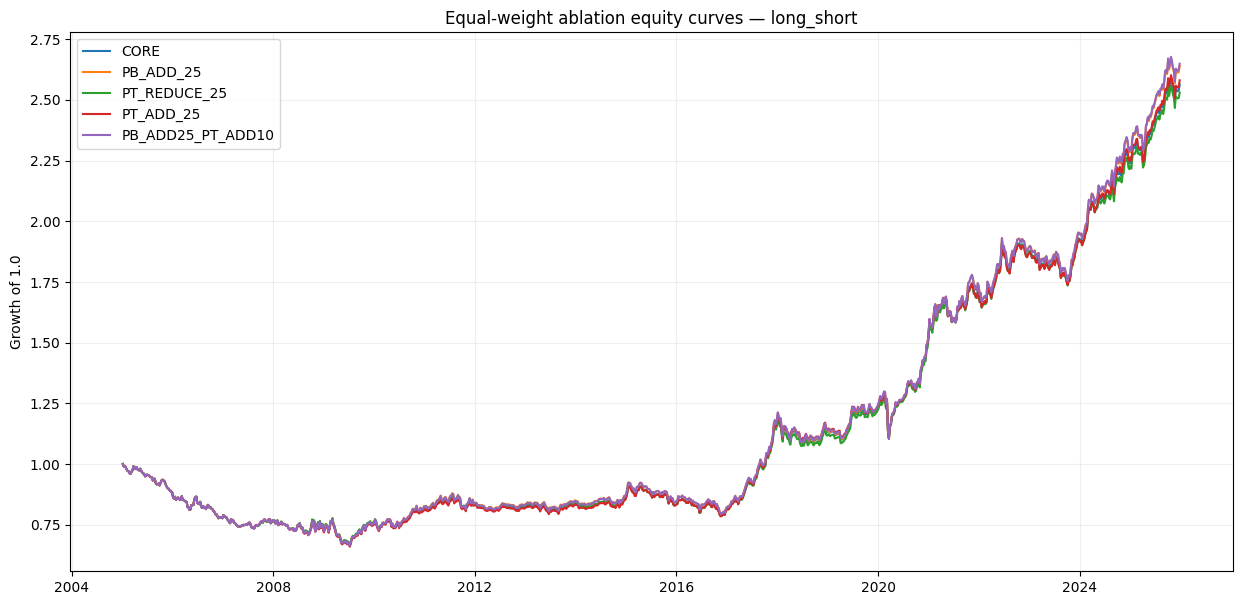

In [14]:

# ============================================================
# 4.14 — SELECTED AGGREGATE EQUITY CURVES
# ============================================================
PLOT_DIRECTION = "long_short"
PLOT_VARIANTS = [
    "CORE",
    "PB_ADD_25",
    "PT_REDUCE_25",
    "PT_ADD_25",
    "PB_ADD25_PT_ADD10",
]

fig, ax = plt.subplots(figsize=(15, 7))

for variant in PLOT_VARIANTS:
    r = aggregate_returns[(variant, PLOT_DIRECTION)].fillna(0.0)
    equity = (1 + r).cumprod()
    ax.plot(equity.index, equity, label=variant)

ax.set_title(f"Equal-weight ablation equity curves — {PLOT_DIRECTION}")
ax.set_ylabel("Growth of 1.0")
ax.legend()
ax.grid(alpha=0.2)
plt.show()



## 4.15 Drawdown comparison

Trend-following modifications may be valuable even when their CAGR contribution is modest if they improve downside behaviour.


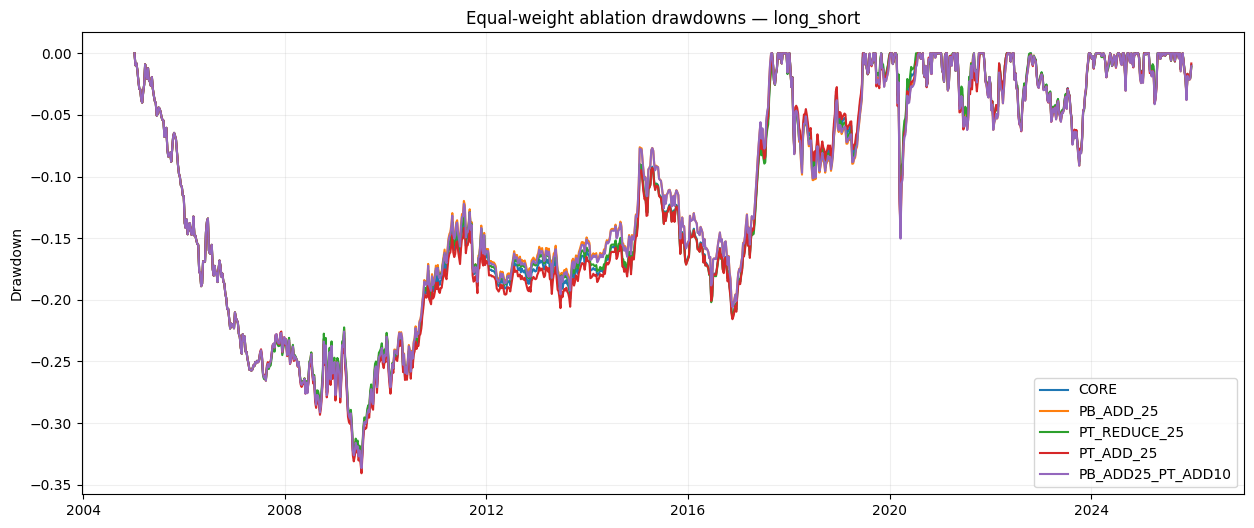

In [15]:

# ============================================================
# 4.15 — DRAWDOWN CHART
# ============================================================
fig, ax = plt.subplots(figsize=(15, 6))

for variant in PLOT_VARIANTS:
    r = aggregate_returns[(variant, PLOT_DIRECTION)].fillna(0.0)
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    ax.plot(dd.index, dd, label=variant)

ax.set_title(f"Equal-weight ablation drawdowns — {PLOT_DIRECTION}")
ax.set_ylabel("Drawdown")
ax.legend()
ax.grid(alpha=0.2)
plt.show()



## 4.16 Stress-period inspection

The dates below are fixed in advance as economically meaningful historical episodes rather than selected according to SuperbCommand performance.

They are included only if they overlap the available prototype data.

This is descriptive and not an optimisation criterion.


In [16]:

# ============================================================
# 4.16 — FIXED STRESS-PERIOD SUMMARY
# ============================================================
STRESS_PERIODS = {
    "Global Financial Crisis": ("2007-07-01", "2009-03-31"),
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for name, (start, end) in STRESS_PERIODS.items():
    for variant in ["CORE", "PB_ADD_25", "PT_REDUCE_25", "PT_ADD_25", "PB_ADD25_PT_ADD10"]:
        for mode in DIRECTION_MODES:
            r = aggregate_returns[(variant, mode)].loc[start:end].dropna()
            if len(r) == 0:
                continue

            stress_rows.append({
                "period": name,
                "variant": variant,
                "direction_mode": mode,
                "weeks": len(r),
                "total_return": (1 + r).prod() - 1,
                "max_drawdown": max_drawdown_from_returns(r),
                "worst_week": r.min(),
            })

stress_summary = pd.DataFrame(stress_rows)
display(stress_summary)


,period,variant,direction_mode,weeks,total_return,max_drawdown,worst_week
0,Global Financial Crisis,CORE,long_cash,91,-0.025419,-0.101422,-0.020196
1,Global Financial Crisis,CORE,long_short,91,-0.034461,-0.077829,-0.052621
2,Global Financial Crisis,PB_ADD_25,long_cash,91,-0.021366,-0.102586,-0.020888
3,Global Financial Crisis,PB_ADD_25,long_short,91,-0.030546,-0.079547,-0.053040
4,Global Financial Crisis,PT_REDUCE_25,long_cash,91,-0.020168,-0.098150,-0.020196
5,Global Financial Crisis,PT_REDUCE_25,long_short,91,-0.029223,-0.071333,-0.052621
6,Global Financial Crisis,PT_ADD_25,long_cash,91,-0.031170,-0.106533,-0.020196
7,Global Financial Crisis,PT_ADD_25,long_short,91,-0.040197,-0.087270,-0.052621
8,Global Financial Crisis,PB_ADD25_PT_ADD10,long_cash,91,-0.023612,-0.103941,-0.020888
9,Global Financial Crisis,PB_ADD25_PT_ADD10,long_short,91,-0.032785,-0.083254,-0.053040



## 4.17 Save research outputs

These outputs will be used by Notebook 05, but Notebook 05 should still reconstruct portfolio weights from underlying strategy returns rather than treating this equal-weight aggregate as final.


In [17]:

# ============================================================
# 4.17 — SAVE OUTPUTS
# ============================================================
OUT_DIR = PATHS["results"]

MARKET_METRICS_PATH = OUT_DIR / "04_market_strategy_metrics.csv"
AGG_METRICS_PATH = OUT_DIR / "04_equal_weight_ablation_metrics.csv"
ABLATION_PATH = OUT_DIR / "04_ablation_deltas.csv"
CONSISTENCY_PATH = OUT_DIR / "04_market_consistency.csv"
STRESS_PATH = OUT_DIR / "04_stress_period_summary.csv"
RETURN_PANEL_PATH = PATHS["data_processed"] / "04_strategy_return_panel.parquet"

market_metrics.to_csv(MARKET_METRICS_PATH, index=False)
aggregate_metrics.to_csv(AGG_METRICS_PATH, index=False)
ablation_deltas.to_csv(ABLATION_PATH, index=False)
consistency_summary.to_csv(CONSISTENCY_PATH, index=False)
stress_summary.to_csv(STRESS_PATH, index=False)

# Save all strategy returns in a MultiIndex-column panel.
return_series = {}
for (ticker, variant, mode), bt in backtests.items():
    return_series[(ticker, variant, mode)] = bt["net_strategy_return"]

return_panel = pd.concat(return_series, axis=1).sort_index()
return_panel.columns = pd.MultiIndex.from_tuples(
    return_panel.columns,
    names=["ticker", "variant", "direction_mode"]
)
return_panel.to_parquet(RETURN_PANEL_PATH)

print("Saved:")
for p in [
    MARKET_METRICS_PATH,
    AGG_METRICS_PATH,
    ABLATION_PATH,
    CONSISTENCY_PATH,
    STRESS_PATH,
    RETURN_PANEL_PATH,
]:
    print(" ", p)


Saved:
  /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/04_market_strategy_metrics.csv
  /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/04_equal_weight_ablation_metrics.csv
  /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/04_ablation_deltas.csv
  /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/04_market_consistency.csv
  /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/04_stress_period_summary.csv
  /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/04_strategy_return_panel.parquet



## 4.18 Validation suite

Notebook 04 should pass only if:

- no holdout data is present;
- all 14 coarse strategy combinations are represented;
- target exposures are applied with a one-week lag;
- no impossible exposure values are produced;
- output files are written successfully.


In [18]:

# ============================================================
# 4.18 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = panel.index.get_level_values("date").max() <= RESEARCH_END
checks["all_markets_present"] = set(tickers) == set(meta.index)

expected_combinations = len(VARIANTS) * len(DIRECTION_MODES)
actual_combinations = aggregate_metrics[["variant", "direction_mode"]].drop_duplicates().shape[0]
checks["all_strategy_combinations_present"] = actual_combinations == expected_combinations

# Confirm no target exposure exceeds designed coarse bounds.
all_targets = []
for bt in backtests.values():
    all_targets.extend(bt["target_exposure"].dropna().tolist())

checks["exposures_within_bounds"] = (
    min(all_targets) >= -1.0
    and max(all_targets) <= 1.25
)

# Check one-week execution lag on all backtests.
lag_ok = True
for bt in backtests.values():
    a = bt["exposure"]
    b = bt["target_exposure"].shift(1)
    if not a.equals(b):
        lag_ok = False
        break
checks["one_week_signal_lag_enforced"] = lag_ok

checks["return_panel_written"] = RETURN_PANEL_PATH.exists()
checks["metric_outputs_written"] = all(
    p.exists()
    for p in [
        MARKET_METRICS_PATH,
        AGG_METRICS_PATH,
        ABLATION_PATH,
        CONSISTENCY_PATH,
        STRESS_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 04 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 04 STATUS: PASS")
print("=" * 78)
print("Coarse strategy ablation completed.")
print("No signal hyperparameters were optimised.")
print("Portfolio construction remains deliberately simple.")
print("2026 holdout: NOT ACCESSED")
print("Proceed to Notebook 05 — Portfolio Construction.")


                            check  passed
                   holdout_absent    True
              all_markets_present    True
all_strategy_combinations_present    True
          exposures_within_bounds    True
     one_week_signal_lag_enforced    True
             return_panel_written    True
           metric_outputs_written    True

NOTEBOOK 04 STATUS: PASS
Coarse strategy ablation completed.
No signal hyperparameters were optimised.
Portfolio construction remains deliberately simple.
2026 holdout: NOT ACCESSED
Proceed to Notebook 05 — Portfolio Construction.


In [19]:

# ============================================================
# 4.19 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "04",
    "notebook_name": "Strategy Engine & Coarse Ablation",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_accessed": False,
    "execution_lag_weeks": 1,
    "one_way_cost_bps": ONE_WAY_COST_BPS,
    "direction_modes": list(DIRECTION_MODES),
    "variants": VARIANTS.reset_index().to_dict(orient="records"),
    "markets": tickers,
    "outputs": {
        "market_metrics": str(MARKET_METRICS_PATH),
        "aggregate_metrics": str(AGG_METRICS_PATH),
        "ablation_deltas": str(ABLATION_PATH),
        "market_consistency": str(CONSISTENCY_PATH),
        "stress_summary": str(STRESS_PATH),
        "strategy_return_panel": str(RETURN_PANEL_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "04_strategy_engine_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/04_strategy_engine_manifest.json



---

# End of Notebook 04

## What Notebook 04 tests

Notebook 04 answers four coarse design questions:

1. **Does strategic long/short improve on strategic long/cash?**
2. **Does adding during pullbacks help?**
3. **Should the current `profit_taking` state reduce, preserve, or increase exposure?**
4. **Are any improvements broad across markets rather than driven by one asset?**

It does not attempt to find optimal exposure percentages.

## Next notebook

**Notebook 05 — Portfolio Construction**

Notebook 05 should take the surviving strategy variants and compare:

- equal weighting;
- inverse volatility;
- Equal Risk Contribution;
- volatility-targeted ERC;

while keeping the signal specification fixed.
